In [1]:
# ================================================
# 1. Imports
# ================================================
import mlflow
import mlflow.sklearn
import mlflow.xgboost

import numpy as np
import pandas as pd
print('pandas version: ',pd.__version__)
pd.Int64Index = pd.Index
pd.Float64Index = pd.Index


import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
#import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from IPython.display import display
pd.options.display.max_columns = None
pd.options.display.max_rows = 30
pd.get_option("display.max_rows")

import warnings
warnings.filterwarnings('ignore')

import os
from pathlib import Path

# Create a process data directory if it doesn't already exist
processed_data_path = Path("/Volumes/SANDISKUSBC/MLOps/hdb_price_prediction_mlops/data/processed")

pandas version:  2.3.3


In [2]:
train_df= pd.read_csv(processed_data_path/'featured_train.csv')
eval_df= pd.read_csv(processed_data_path/'featured_eval.csv')

print(train_df.columns)
train_df.head()

Index(['month', 'town', 'blk_no', 'road_name', 'building', 'postal',
       'resale_price', 'storey_range', 'flat_type', 'flat_model',
       'lease_commence_date', 'remaining_lease_years',
       'remaining_lease_months', 'floor_area_sqm', 'floor_area_sqft',
       'price_per_sqft', 'planning_area_ura', 'region_ura', 'x', 'y',
       'latitude', 'longitude', 'closest_mrt_station',
       'distance_to_mrt_meters', 'transport_type', 'line_color',
       'distance_to_cbd', 'closest_pri_school',
       'distance_to_pri_school_meters', 'quarter', 'resale_price_index',
       'flat_type_rank', 'region_ura_rank', 'town_rank', 'storey_range_rank',
       'flat_model_rank'],
      dtype='object')


,month,town,blk_no,road_name,building,postal,resale_price,storey_range,flat_type,flat_model,lease_commence_date,remaining_lease_years,remaining_lease_months,floor_area_sqm,floor_area_sqft,price_per_sqft,planning_area_ura,region_ura,x,y,latitude,longitude,closest_mrt_station,distance_to_mrt_meters,transport_type,line_color,distance_to_cbd,closest_pri_school,distance_to_pri_school_meters,quarter,resale_price_index,flat_type_rank,region_ura_rank,town_rank,storey_range_rank,flat_model_rank
0,2022-03-01,CHOA CHU KANG,816A,KEAT HONG LINK,KEAT HONG MIRAGE,681816,550000.0,19 TO 21,4 ROOM,Model A,2017-09-01,94,6,92.0,990.2788,555.399146,CHOA CHU KANG,WEST REGION,18596.867822,39780.256257,1.376032,103.748825,Keat Hong,285.529337,LRT,Grey,15288.837561,SOUTH VIEW PRIMARY SCHOOL,684.627817,2022 1Q,159.5,3,1,10,6,5
1,2022-04-01,CHOA CHU KANG,205,CHOA CHU KANG CENTRAL,NIL,680205,522888.0,01 TO 03,5 ROOM,Improved,1989-05-01,66,0,122.0,1313.1958,398.179769,CHOA CHU KANG,WEST REGION,18567.392344,40321.553471,1.380927,103.748560,Keat Hong,262.790995,LRT,Grey,15675.388451,SOUTH VIEW PRIMARY SCHOOL,266.995332,2022 2Q,163.9,4,1,10,0,6
2,2022-04-01,CHOA CHU KANG,818C,CHOA CHU KANG AVENUE 1,KEAT HONG MIRAGE,683818,595000.0,01 TO 03,5 ROOM,Improved,2017-09-01,94,6,112.0,1205.5568,493.547878,CHOA CHU KANG,WEST REGION,18521.801436,39856.591264,1.376722,103.748150,Keat Hong,231.162515,LRT,Grey,15395.662063,SOUTH VIEW PRIMARY SCHOOL,585.204929,2022 2Q,163.9,4,1,10,0,6
3,2022-04-01,CHOA CHU KANG,7,TECK WHYE AVENUE,TECK WHYE HEIGHTS I,680007,645000.0,22 TO 24,5 ROOM,Model A,1984-03-01,60,11,132.0,1420.8348,453.958476,CHOA CHU KANG,WEST REGION,19230.883013,40382.086654,1.381474,103.754522,Phoenix,499.411641,LRT,Grey,15240.120250,TECK WHYE PRIMARY SCHOOL,276.758965,2022 2Q,163.9,4,1,10,7,5
4,2022-05-01,CHOA CHU KANG,111,TECK WHYE LANE,NIL,680111,420000.0,01 TO 03,4 ROOM,Model A,1989-09-01,66,5,103.0,1108.6817,378.828297,CHOA CHU KANG,WEST REGION,18961.791376,39984.533910,1.377879,103.752104,Teck Whye,222.457650,LRT,Grey,15157.140648,TECK WHYE PRIMARY SCHOOL,651.676254,2022 2Q,163.9,3,1,10,0,5


In [3]:
# 1. Prepare data
mycols = ['flat_type_rank', 'region_ura_rank', 'town_rank','storey_range_rank','flat_model_rank'
         ,'distance_to_cbd', 'floor_area_sqm', 'remaining_lease_years','resale_price_index']
target = 'resale_price'

In [4]:
# Identify all columns in train_df that are of type 'object'
categorical_cols = train_df[mycols].select_dtypes(include=['object']).columns
numeric_cols = train_df[mycols].select_dtypes(include=['number']).columns

# Convert these columns to 'category' dtype
for col in categorical_cols:
    train_df[col] = train_df[col].astype('category')
    eval_df[col] = eval_df[col].astype('category')
    
    # If you also have hold_df active, uncomment the next line:
    # hold_df[col] = hold_df[col].astype('category')

print(f"Converted {len(categorical_cols)} columns to category dtype:")
print(list(categorical_cols))

# Verify the changes
print(train_df[mycols].info())

Converted 0 columns to category dtype:
[]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168869 entries, 0 to 168868
Data columns (total 9 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   flat_type_rank         168869 non-null  int64  
 1   region_ura_rank        168869 non-null  int64  
 2   town_rank              168869 non-null  int64  
 3   storey_range_rank      168869 non-null  int64  
 4   flat_model_rank        168869 non-null  int64  
 5   distance_to_cbd        168869 non-null  float64
 6   floor_area_sqm         168869 non-null  float64
 7   remaining_lease_years  168869 non-null  int64  
 8   resale_price_index     168869 non-null  float64
dtypes: float64(3), int64(6)
memory usage: 11.6 MB
None


In [5]:
X_train = train_df[mycols]
y_train = train_df[target]

X_eval = eval_df[mycols]
y_eval = eval_df[target]

# Helper function for evaluation
def evaluate_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, r2

### Start MLflow Experiment

In [7]:
# Set MLflow experiment (Optional, creates one if it doesn't exist)
mlflow.set_experiment("hdb_explore")
mlflow.set_tracking_uri('http://127.0.0.1:5000/')#("http://localhost:5000")
#import subprocess
#subprocess.Popen(["mlflow", "ui", "--port", "5000"])

In [8]:

print("--- Training ElasticNet (Scaled + OneHotEncoded) ---")
with mlflow.start_run(run_name="ElasticNet_Scaled_OHE"):
    
    # Create the column transformer
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), numeric_cols),
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
        ]
    )
    
    # Create the full pipeline
    en_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('elasticnet', ElasticNet(alpha=0.1, l1_ratio=0.5,random_state=42))
    ])
    
    en_pipeline.fit(X_train, y_train)
    
    y_pred_en = en_pipeline.predict(X_eval)
    rmse, mae, r2 = evaluate_metrics(y_eval, y_pred_en)
    
    mlflow.log_metrics({"rmse": rmse, "mae": mae, "r2": r2})
    # Logging the pipeline ensures transformations are packaged with the model
    #mlflow.sklearn.log_model(en_pipeline, "elasticnet_pipeline_model")
    
    print(f"Metrics -> RMSE: {rmse:.2f}, MAE: {mae:.2f}, R2: {r2:.4f}")
    
    # Extract generated feature names from the preprocessor to map coefficients
    feature_names = en_pipeline.named_steps['preprocessor'].get_feature_names_out()
    en_model_step = en_pipeline.named_steps['elasticnet']
    
    coef_df = pd.DataFrame({
        'Feature': feature_names,
        'Coefficient': en_model_step.coef_
    }).sort_values(by='Coefficient', ascending=False)
    
    print("\nElasticNet Coefficients Report:")
    display(coef_df)


--- Training ElasticNet (Scaled + OneHotEncoded) ---
Metrics -> RMSE: 84448.10, MAE: 60899.21, R2: 0.7995

ElasticNet Coefficients Report:


,Feature,Coefficient
6,num__floor_area_sqm,70575.570097
8,num__resale_price_index,55196.054980
7,num__remaining_lease_years,45025.705324
0,num__flat_type_rank,33073.139585
3,num__storey_range_rank,30623.180227
4,num__flat_model_rank,20825.953451
1,num__region_ura_rank,11594.430731
2,num__town_rank,-812.182674
5,num__distance_to_cbd,-63323.088413


🏃 View run ElasticNet_Scaled_OHE at: http://127.0.0.1:5000/#/experiments/697179003652359077/runs/bf56ede5689444b8b267902d92639405
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/697179003652359077



--- Training XGBRegressor ---
Metrics -> RMSE: 54216.37, MAE: 40447.19, R2: 0.9174


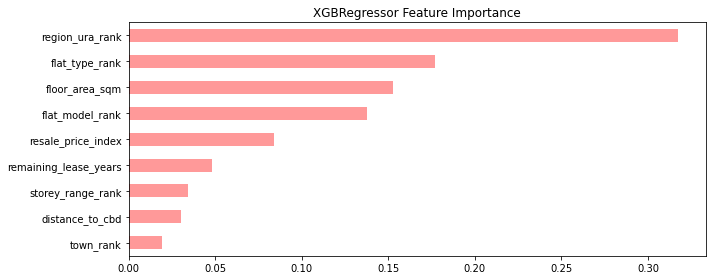

🏃 View run XGBRegressor at: http://127.0.0.1:5000/#/experiments/697179003652359077/runs/c0e5661807da4060a9cbfa48236e5e41
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/697179003652359077


In [9]:

# -------------------------------------------------------------------
# 3. XGBRegressor
# -------------------------------------------------------------------
print("\n" + "="*50 + "\n--- Training XGBRegressor ---")
with mlflow.start_run(run_name="XGBRegressor"):
    #xgb_model = XGBRegressor(enable_categorical=True,random_state=42)
    xgb_model = XGBRegressor(random_state=42)
    xgb_model.fit(X_train, y_train)
    
    y_pred_xgb = xgb_model.predict(X_eval)
    rmse, mae, r2 = evaluate_metrics(y_eval, y_pred_xgb)
    
    mlflow.log_metrics({"rmse": rmse, "mae": mae, "r2": r2})
    #mlflow.xgboost.log_model(xgb_model, "xgb_model")
    
    print(f"Metrics -> RMSE: {rmse:.2f}, MAE: {mae:.2f}, R2: {r2:.4f}")
    
    # Plot feature importance
    plt.figure(figsize=(10, 4))
    feat_imp_xgb = pd.Series(xgb_model.feature_importances_, index=mycols).sort_values(ascending=True)
    feat_imp_xgb.plot(kind='barh', color='#ff9999')
    plt.title('XGBRegressor Feature Importance')
    plt.tight_layout()
    plt.show()



--- Training RandomForestRegressor ---
Metrics -> RMSE: 55073.07, MAE: 40528.79, R2: 0.9147


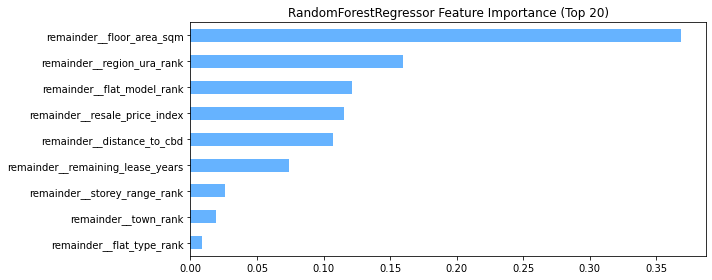

🏃 View run RandomForestRegressor at: http://127.0.0.1:5000/#/experiments/697179003652359077/runs/80bc43ad017c44ddab3c8caffeabc8ae
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/697179003652359077

Model training and MLflow tracking complete!


In [10]:

# -------------------------------------------------------------------
# 4. RandomForestRegressor
# -------------------------------------------------------------------
print("\n" + "="*50 + "\n--- Training RandomForestRegressor ---")
with mlflow.start_run(run_name="RandomForestRegressor"):
    transformers = []
    # Check if the Index or list is not empty
    if len(categorical_cols) > 0:
        transformers.append(
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
        )

    preprocessor_rf = ColumnTransformer(
        transformers=transformers,
        remainder='passthrough' 
    )

    
    # Create the full pipeline
    rf_pipeline = Pipeline([
        ('preprocessor', preprocessor_rf),
        ('rf', RandomForestRegressor(random_state=42, n_jobs=-1))
    ])
    
    rf_pipeline.fit(X_train, y_train)
    
    y_pred_rf = rf_pipeline.predict(X_eval)
    rmse, mae, r2 = evaluate_metrics(y_eval, y_pred_rf)
    
    mlflow.log_metrics({"rmse": rmse, "mae": mae, "r2": r2})
    
    # Logging the pipeline ensures transformations are packaged with the model
    #mlflow.sklearn.log_model(rf_pipeline, "rf_pipeline_model")
    
    print(f"Metrics -> RMSE: {rmse:.2f}, MAE: {mae:.2f}, R2: {r2:.4f}")
    
    # Extract feature names and the fitted model step for plotting
    feature_names_rf = rf_pipeline.named_steps['preprocessor'].get_feature_names_out()
    rf_model_step = rf_pipeline.named_steps['rf']
    
    # Plot feature importance (Top 20)
    plt.figure(figsize=(10, 4))
    feat_imp_rf = pd.Series(rf_model_step.feature_importances_, index=feature_names_rf).sort_values(ascending=False).head(20).sort_values(ascending=True)
    feat_imp_rf.plot(kind='barh', color='#66b3ff')
    plt.title('RandomForestRegressor Feature Importance (Top 20)')
    plt.tight_layout()
    plt.show()

print("\nModel training and MLflow tracking complete!")
